In [ ]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.stem import PorterStemmer
nltk.download('stopwords')
from nltk.corpus import stopwords
StopWords = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sachi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV,StratifiedKFold
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import pickle


In [6]:
data = pd.read_csv('d:/git-project/ML-pratice/data/amazon_alexa.tsv', sep='\t')
data.tail(20)

,rating,date,variation,verified_reviews,feedback
3130,5,30-Jul-18,Black Dot,Use the product for music and it’s great!,1
3131,5,30-Jul-18,Black Dot,Easy to set-up and to use.,1
3132,5,30-Jul-18,Black Dot,It works great!!,1
3133,4,30-Jul-18,White Dot,I like having more Alexa devices in my house a...,1
3134,5,30-Jul-18,Black Dot,PHENOMENAL,1
3135,5,30-Jul-18,White Dot,I loved it does exactly what it says,1
3136,4,30-Jul-18,Black Dot,I used it to control my smart home devices. Wo...,1
3137,5,30-Jul-18,Black Dot,Very convenient,1
3138,5,30-Jul-18,White Dot,Este producto llegó y a la semana se quedó sin...,1
3139,5,30-Jul-18,White Dot,Easy to set up Ready to use in minutes.,1


In [7]:
print(f"Feature names: {data.columns.values}")

Feature names: ['rating' 'date' 'variation' 'verified_reviews' 'feedback']


In [8]:
data.columns.values

array(['rating', 'date', 'variation', 'verified_reviews', 'feedback'],
      dtype=object)

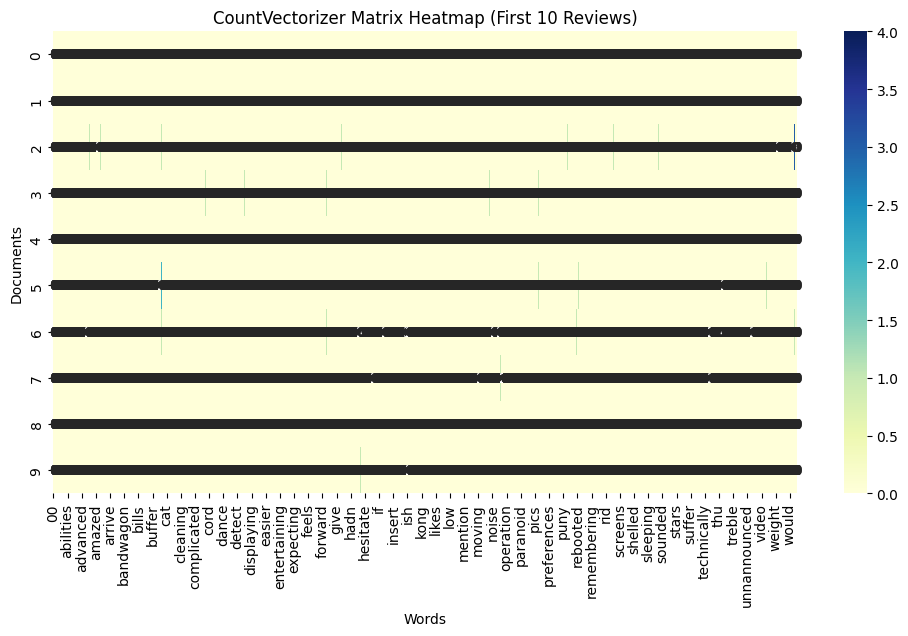

In [9]:
# Visualize CountVectorizer matrix as a heatmap using your dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Load your dataset
data = pd.read_csv('d:/git-project/ML-pratice/data/amazon_alexa.tsv', sep='\t')

# Use the 'verified_reviews' column for text data (update if your column name is different)
documents = data['verified_reviews'].astype(str).tolist()

# Create CountVectorizer instance and transform data
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents)

# Convert to DataFrame for visualization (show only first 10 documents for clarity)
df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df_sample = df.head(10)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_sample, annot=True, cmap="YlGnBu", cbar=True)
plt.title("CountVectorizer Matrix Heatmap (First 10 Reviews)")
plt.xlabel("Words")
plt.ylabel("Documents")
plt.show()

In [10]:
data[data['verified_reviews'].isna()==True]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [11]:
data.dropna(inplace=True)

In [12]:
data.shape

(3149, 5)

In [13]:
data['lenght'] = data['verified_reviews'].apply(len)
data.head()

,rating,date,variation,verified_reviews,feedback,lenght
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1,195
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,172
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


In [14]:
data.iloc[10]

rating                                                              5
date                                                        30-Jul-18
variation                                            Charcoal Fabric 
verified_reviews    I sent it to my 85 year old Dad, and he talks ...
feedback                                                            1
lenght                                                             63
Name: 10, dtype: object

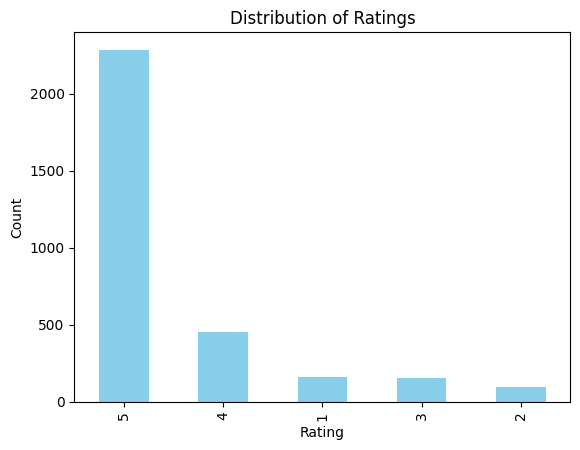

In [15]:
data['rating'].value_counts().plot.bar(color='skyblue')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

([<matplotlib.patches.Wedge at 0x204fa6296a0>,
 [Text(-0.7168725143844202, 0.8343223586361325, ''),
  Text(0.32799956710287353, -1.049960134471937, ''),
  Text(0.8733843392573287, -0.6687299873192764, ''),
  Text(1.036590872592624, -0.3680752135877424, ''),
  Text(1.0950632799421605, -0.10409809278904968, '')])

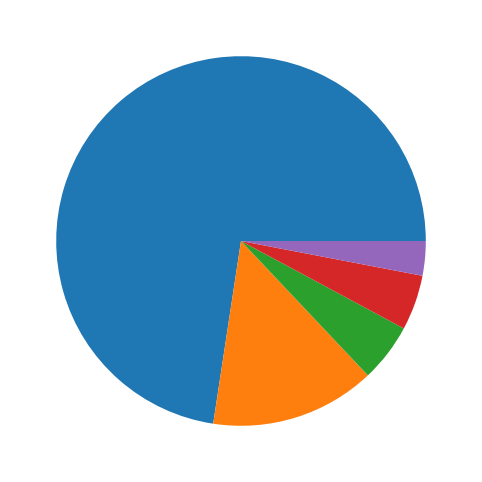

In [16]:
plt.figure(figsize=(10,6))
plt.pie(data['rating'].value_counts()/data.shape[0])

In [17]:
data[data['feedback'] == 0]['rating'].value_counts()

rating
1    161
2     95
Name: count, dtype: int64

In [18]:
data[data['feedback'] == 1]['rating'].value_counts()

rating
5    2286
4     455
3     152
Name: count, dtype: int64

<Axes: xlabel='feedback'>

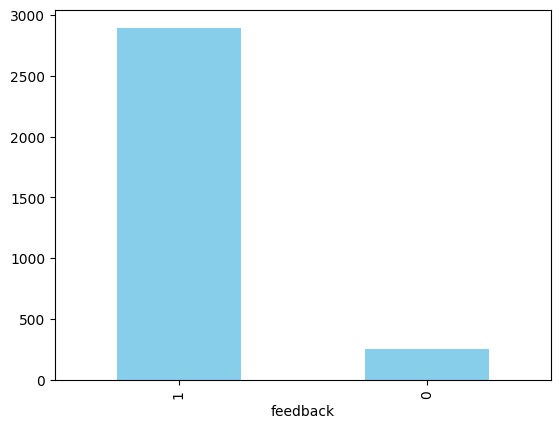

In [19]:
data['feedback'].value_counts().plot.bar(color='skyblue')

([<matplotlib.patches.Wedge at 0x204fa540910>,
 [Text(-1.0643191887246546, 0.2778932610058999, ''),
  Text(1.0643190805089426, -0.27789367546707394, '')])

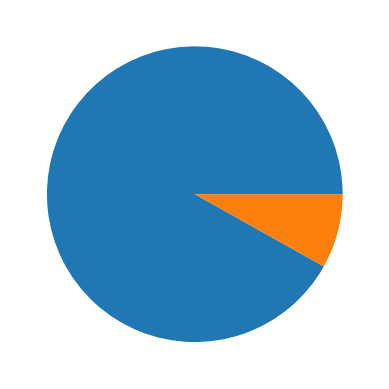

In [20]:
plt.pie(data['feedback'].value_counts()/data.shape[0])

<Axes: xlabel='variation'>

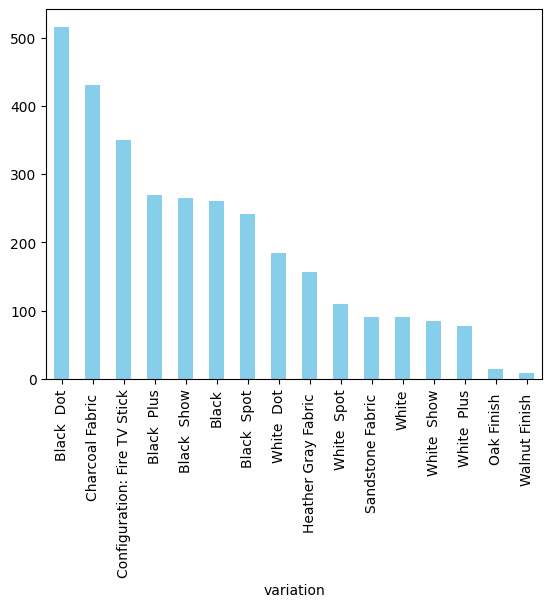

In [21]:
data['variation'].value_counts().plot.bar(color='skyblue')

In [22]:
Mean = data.groupby('variation')['rating'].mean()
Mean = Mean.sort_values(ascending=False)

Text(0.5, 1.0, 'Average Rating by Variation')

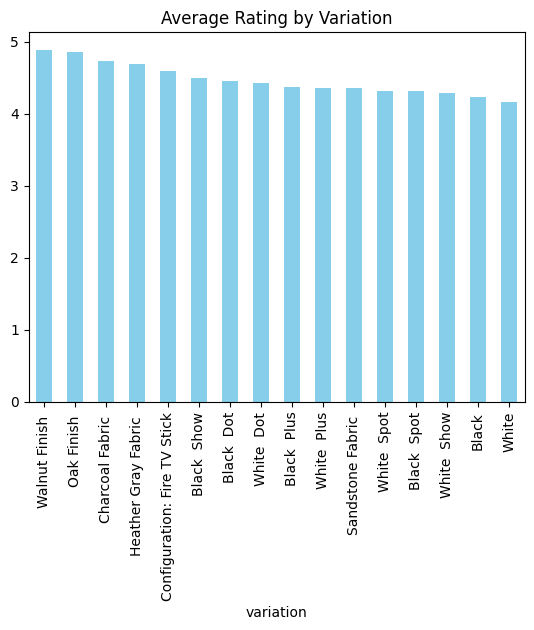

In [23]:
Mean.plot.bar(color='skyblue')
plt.title('Average Rating by Variation')

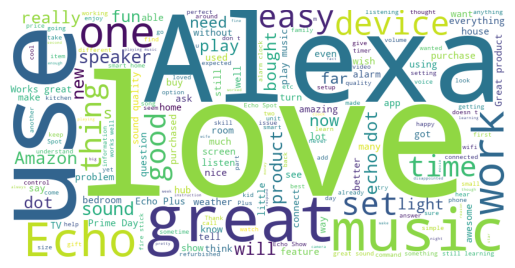

In [24]:
wc = WordCloud(width=800, height=400, background_color='white').generate(' '.join(str(r) for r in data['verified_reviews']))
plt.imshow(wc)
plt.axis('off')
plt.show()


In [27]:
import re
corpus = []
stemmer = PorterStemmer()
for review in data['verified_reviews']:
    review = re.sub('[^a-zA-Z]', ' ', str(review))
    review = review.lower().split()
    review = [stemmer.stem(word) for word in review if word not in StopWords]
    review = ' '.join(review)
    corpus.append(review)

In [28]:
cv = CountVectorizer(max_features=2500)
x = cv.fit_transform(corpus).toarray()
y = data['feedback'].values
y

array([1, 1, 1, ..., 1, 1, 1], shape=(3149,))

In [29]:
pickle.dump(cv, open('cv.pkl', 'wb'))

In [30]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(2519, 2500)),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(630, 2500)),
 array([1, 1, 0, ..., 1, 1, 1], shape=(2519,)),
 array([1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
        1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,

In [31]:
X_train.max(),X_test.max()

(np.int64(12), np.int64(6))

In [32]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train,X_test

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(2519, 2500)),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(630, 2500)))

# Random Forest

In [33]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

0.9928543072647876
0.9253968253968254


Text(0.5, 1.0, 'Model Accuracy')

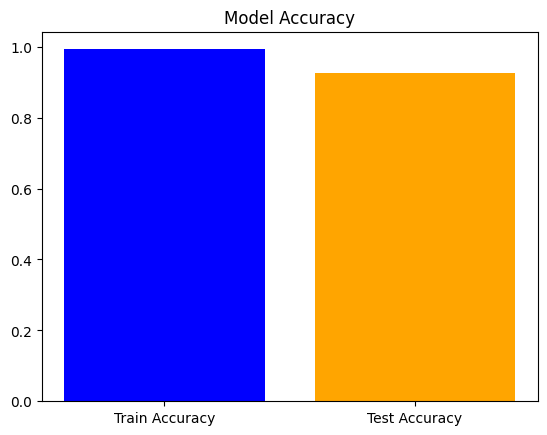

In [34]:
print(model_rf.score(X_train,y_train))
print(model_rf.score(X_test,y_test))
import matplotlib.pyplot as plt
plt.bar(['Train Accuracy', 'Test Accuracy'], [model_rf.score(X_train,y_train), model_rf.score(X_test,y_test)], color=['blue', 'orange'])
plt.title('Model Accuracy')

In [48]:
y_pred_rf = model_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)


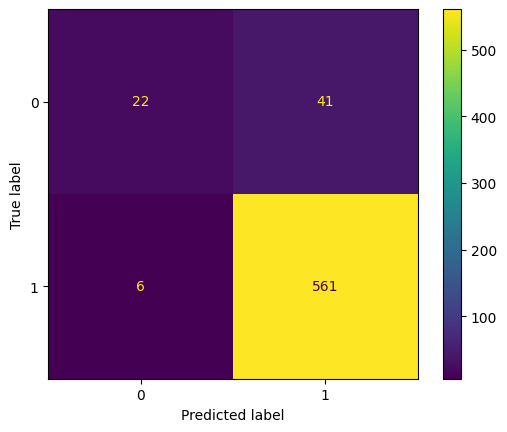

In [36]:
cm_display = ConfusionMatrixDisplay(cm).plot()

In [37]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train,y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [38]:
print(model_dt.score(X_train,y_train))
print(model_dt.score(X_test,y_test))

0.9928543072647876
0.9079365079365079


In [39]:
y_pred_dt = model_dt.predict(X_test)
cm_dt = confusion_matrix(y_test, y_pred_dt)

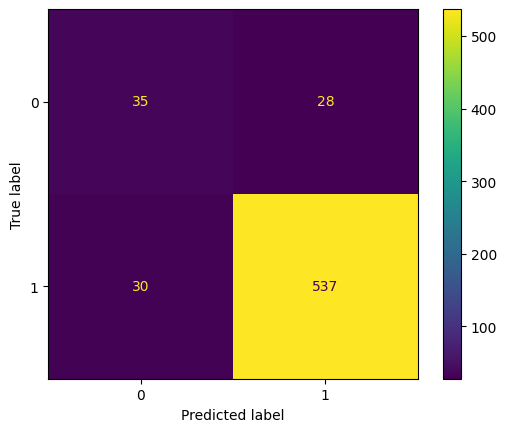

In [40]:
cm_display = ConfusionMatrixDisplay(cm_dt).plot()
cm_display

In [41]:
model_xg = XGBClassifier()
model_xg.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [42]:
print(model_xg.score(X_train,y_train))
print(model_xg.score(X_test,y_test))

0.9718142119888845
0.919047619047619


In [44]:
y_pred_xg = model_xg.predict(X_test)

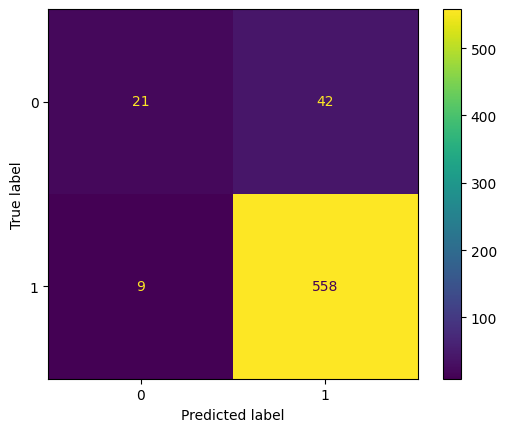

In [45]:
cm_xg = confusion_matrix(y_test, y_pred_xg)
cm_display = ConfusionMatrixDisplay(cm_xg).plot()
cm_display

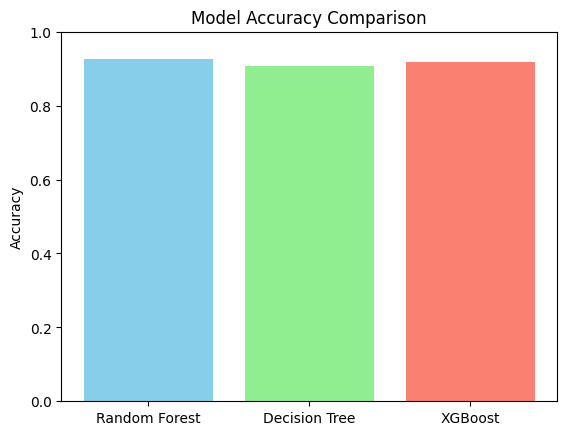

In [49]:
from sklearn.metrics import accuracy_score

accuracies = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_xg)
]

model_names = ['Random Forest', 'Decision Tree', 'XGBoost']

plt.bar(model_names, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

In [51]:
# Example review
review_text = "It provide good analysis"

# Preprocess the review
import re
review = re.sub('[^a-zA-Z]', ' ', review_text)
review = review.lower().split()
review = [stemmer.stem(word) for word in review if word not in StopWords]
review = ' '.join(review)

# Load CountVectorizer
import pickle
cv = pickle.load(open('cv.pkl', 'rb'))

# Transform the review
X_new = cv.transform([review]).toarray()

# If you used scaling in your pipeline, apply the same scaler
X_new_scl = scaler.transform(X_new)

# Predict with each model
pred_rf = model_rf.predict(X_new_scl)[0]
pred_dt = model_dt.predict(X_new_scl)[0]
pred_xgb = model_xg.predict(X_new_scl)[0]

print("Random Forest Prediction:", pred_rf)
print("Decision Tree Prediction:", pred_dt)
print("XGBoost Prediction:", pred_xgb)

Random Forest Prediction: 1
Decision Tree Prediction: 1
XGBoost Prediction: 1
